In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.preprocessing import MinMaxScaler
from bct.algorithms.reference import latmio_und, randmio_und
from itertools import combinations
from scipy.sparse.csgraph import shortest_path

The Small-World Propensity, $\phi$, is defined as:

$\phi = 1 - \sqrt{\frac{\Delta^2_C + \Delta^2_L}{2}}$,

where 

$\Delta_C = \frac{C_{latt} - C_{obs}}{C_{latt} - C_{rand}}$,

and 

$\Delta_L = \frac{L_{obs} - L_{rand}}{L_{latt} - L_{rand}}$.

**Important note:** $\phi$ should be bounded by $[0, 1]$, so $\Delta_L \text{and} \Delta_C$ are bounded also bounded, meaning that if $\Delta_C$ or $\Delta_L$ > 1, set it 1, and if $\Delta_C$ or $\Delta_L$ < 0, set it to 0.


We need to calculate the clustering coefficient, $C_{obs}$, which is the average of all local clustering coefficients. Muldoon *et al.* use a formula from Onnela *et al.* for the local clustering coefficient of a weighted network:
$c_i = \frac{1}{k_i(k_i - 1)}\sum_{j, k} (\hat{w}_{ij}\hat{w}_{jk}\hat{w}_{ik})^{\frac{1}{3}}$, where $w_{ij}$ is the edge weight, $\hat{w}_{ij} = \frac{w_{ij}}{max(w)}$, and $k_i$ is the number of edges connected to $i$. 

We also need to calculate the characteristic path length, $L = \frac{1}{N(N - 1)} \sum_{i \neq j} d_{ij}$, where $d_{ij}$ is the shortest path between nodes $i$ and $j$. For a weighted network, Muldoon *et al.* define this as $d_{ij} = \frac{1}{w_{ij}}$, where $w_{ij}$ is the edge weight.

We also need to generate a lattice and a random network with the same number of edges and degree distribution as the observed network. **Question:** is it sufficient to latticize and randomize the inputted network, using, e.g., `latmio_und()` and `randmio_und()`? Latticizing clearly makes a new network, but randomizing appears to do nothing, perhaps because every node has degree 267?

In [19]:
def clustering_coefficient(adj):
    """
    Calculates the local clustering coefficient for each node using the method from Onnela et al. and returns the average clustering coefficient across all nodes.

    Inputs
    ---
    adj  :  numpy.ndarray
            Weighted, undirected graph adjacency matrix.

    Returns
    ---
    C  :  float
          Global clustering coefficient for inputted network.
    
    """
    # Ensure floats
    adj = adj.astype(float)

    # Ensure symmetric matrix
    adj = (adj + adj.T) / 2
    # Initialize empty list to store all clustering coefficients
    coeffs = []
    # Get max weight
    w_max = np.max(adj)

    # Loop through all nodes
    for i in range(adj.shape[0]):
        # Calculate normalizing constant
        k_i = np.count_nonzero(adj[i])
        # If i is only connected to one other node, avoid divide by zero error and set the normalizing constant to 0
        if k_i == 1:
            norm = 0
        elif k_i == 0:
            norm = 0
        else:
            norm = 1/(k_i * (k_i - 1))

        # Get list of indices that are not i
        idx_all = np.array(list(range(adj.shape[0])))
        idx = idx_all[idx_all != i]
        # Get all pairwise combinations of indices
        combos = list(combinations(idx, 2))

        # Initialize inner sum
        inner_sum = 0
        # Loop through all cominations
        for j, k in combos:
            # Get weights for ij, ik, and jk
            w_ij = adj[i, j]
            w_jk = adj[j, k]
            w_ik = adj[i, k]
    
            # Calculate normalized weights
            w_hat_ij = w_ij / w_max
            w_hat_jk = w_jk / w_max
            w_hat_ik = w_ik / w_max

            # Calculate product of normalized edge weights
            product = (w_hat_ij * w_hat_jk * w_hat_ik)**(1/3)

            # Add 
            inner_sum += product

        # Calculate local clustering coefficient
        coeff = norm * inner_sum
        # Append local clustering coefficient
        coeffs.append(coeff)
        
    # Average all local coefficients
    C = np.mean(coeffs)

    # Return average clustering coefficient
    return C

In [31]:
def clustering_coefficient2(adj):
    """
    Calculates the local clustering coefficient for each node using the method from Onnela et al. and returns the average clustering coefficient across all nodes.

    Inputs
    ---
    adj  :  numpy.ndarray
            Weighted, undirected graph adjacency matrix.

    Returns
    ---
    C  :  float
          Global clustering coefficient for inputted network.
    
    """
    # Ensure floats
    adj = adj.astype(float)

    # Ensure symmetric matrix
    adj = (adj + adj.T) / 2
    
    # Get max weight, excluding diagonal
    w_max = np.max(adj[~np.eye(adj.shape[0], dtype=bool)])
    if w_max == 0:
        return 0.0

    # Normalize weights
    w_hat = adj / w_max
    # Initialize empty array to store all clustering coefficients
    N = adj.shape[0]
    local_coeffs = np.zeros(N)

    # Loop through each node
    for i in range(N):
        # Find neighbors (nodes with positive weight)
        neighbors = np.where(adj[i] > 0)[0]
        k_i = len(neighbors)

        if k_i < 2:
            local_coeffs[i] = 0
            continue

        # Calculate normalizing constant
        norm = 1.0 / (k_i * (k_i - 1))

        # Sum over all neighbors
        inner_sum = 0
        for idx_j in range(k_i):
            for idx_k in range(idx_j + 1, k_i):
                j = neighbors[idx_j]
                k = neighbors[idx_k]

                # Get normalized weights
                w_ij = w_hat[i, j]
                w_ik = w_hat[i, k]
                w_jk = w_hat[j, k]

                # Calculate inner product
                product = (w_ij * w_ik * w_jk) ** (1/3)
                inner_sum += product
        local_coeffs[i] = norm * inner_sum
        
    # Average all local coefficients
    C = np.mean(local_coeffs)

    # Return average clustering coefficient
    return C

## Check that the characteristic path length implementation is correct. How to handle when two nodes aren't connected?

In [9]:
def characteristic_path_length(adj):
    """
    Calculates the characteristic path length, L. Since this is for weighted networks, the distance between two nodes is defined as the inverse of the weight of the edge connecting the nodes, hence, d_ij = 1/w_ij.

    Inputs
    ---
    adj    Weighted, undirected graph adjacency matrix.

    Returns
    ---
    L      Characteristic path length for inputted network.
    
    """
    
    # Number of nodes
    N = adj.shape[0]
    # Calculate normalizing constant
    norm = 1 / (N * (N - 1))
    # Initialize sum
    running_sum = 0

    # Get all pairs of nodes
    pairs = list(combinations(list(range(adj.shape[0])), 2))
    # Loop through all nodes
    for i, j in pairs:
        # Get edge weight
        w_ij = adj[i, j]
        # Get distance, avoid divide by 0
        if w_ij == 0:
            d_ij = 0
        else:
            d_ij = 1 / w_ij

        # Add distance to running sum
        running_sum += d_ij

    # Normalize running sum by total number of edges
    L = norm * running_sum
    #print(f'Num pairs: {len(pairs)}')
    #print(f'N: {N}')
    #print(f'norm: {norm}')
    #print(f'sum: {running_sum}')
        
    # Return characteristic path length
    return L

In [51]:
def characteristic_path_length(adj):
    """
    Calculates the characteristic path length, L. Since this is for weighted networks, the distance between two nodes is defined as the inverse of the weight of the edge connecting the nodes, hence, d_ij = 1/w_ij.

    Inputs
    ---
    adj    Weighted, undirected graph adjacency matrix.

    Returns
    ---
    L      Characteristic path length for inputted network.
    
    """
    adj = adj.astype(float)
    # Number of nodes
    N = adj.shape[0]
    # Create distance matrix using 1/w_ij
    distance_matrix = np.zeros_like(adj)
    for i in range(N):
        for j in range(N):
            if i == j:
                distance_matrix[i, j] = 0
            elif adj[i, j] > 0:
                distance_matrix[i, j] = 1 / adj[i, j]
            else:
                distance_matrix[i, j] = np.inf
    # Calculate shortest path
    distance_matrix = shortest_path(distance_matrix, method='BF')

    total_sum = 0
    valid_pairs = 0

    for i in range(N):
        for j in range(N):
            if i != j and not np.isinf(distance_matrix[i, j]):
                total_sum += distance_matrix[i, j]
                valid_pairs += 1
    
    # Calculate normalizing constant
    norm = 1 / (N * (N - 1))
    # Calculate characteristic path length
    L = total_sum * norm
    
    return L

In [49]:
def SWP(adj):
    """
    Calculates the Small-World Propensity of a weighted network. Calculates characteristic path length, L, and clustering coefficient, C, of inputted network. Generates latticized and randomized versions of the inputted network and calculates L and C for the generated networks.

    Inputs
    ---
    adj    Weighted, undirected graph adjacency matrix.

    Returns
    ---
    SWP      Small-World Propensity, SWP in [0, 1]
    """

    # Calculate path length and clustering of observed network
    L_obs = characteristic_path_length(adj)
    print(f'L_obs: {L_obs}')
    C_obs = clustering_coefficient(adj)
    print(f'C_obs: {C_obs}')

    # Randomize network
    rand, _ = randmio_und(R=adj, itr=20)
    # Path length of randomized network
    L_rand = characteristic_path_length(rand)
    print(f'L_rand: {L_rand}')
    # Clustering of randomized network
    C_rand = clustering_coefficient(rand)
    print(f'C_rand: {C_rand}')
    
    # Latticize network
    latt, _, _, _ = latmio_und(R=adj, itr=20)
    # Path length of latticized network
    L_latt = characteristic_path_length(latt)
    print(f'L_latt: {L_latt}')
    # Clustering of latticized network
    C_latt = clustering_coefficient(latt)
    print(f'C_latt: {C_latt}')

    # Calculate delta_C, comparing observed clustering to randomized and latticized versions
    delta_C = (C_latt - C_obs) / (C_latt - C_rand)
    # Keep delta_C between [0, 1]
    if delta_C > 1:
        delta_C = 1
    elif delta_C < 0:
        delta_C = 0
    # Calculate delta_L, comparing observed path length to randomized and latticized versions
    delta_L = (L_obs - L_rand) / (L_latt - L_rand)
    # Keep delta_L between [0, 1]
    if delta_L > 1:
        delta_L = 1
    elif delta_L < 0:
        delta_L = 0

    SWP = 1 - np.sqrt(((delta_C ** 2) + (delta_L ** 2) / 2))
    # Keep SWP between [0, 1]
    if SWP > 1:
        SWP = 1
    elif SWP < 0:
        SWP = 0

    return SWP, delta_C, delta_L

In [52]:
swp, delta_C, delta_L = SWP(elegans_adj)
print(f'SWP: {swp}, delta_C: {delta_C}, delta_L: {delta_L}')

L_obs: 0.658265717871239
C_obs: 0.012807892535605487
L_rand: 0.623405024632347
C_rand: 0.004426366315274378
L_latt: 1.5244407244306952
C_latt: 0.020951977885761513
SWP: 0.5064252586087705, delta_C: 0.4928159732799503, delta_L: 0.03868958049796893


In [54]:
swp, delta_C, delta_L = SWP(fc)
print(f'SWP: {swp}, delta_C: {delta_C}, delta_L: {delta_L}')

L_obs: 3.6720331274273543


/tmp/ipykernel_449661/2058034762.py:53: RuntimeWarning: invalid value encountered in scalar power
  product = (w_hat_ij * w_hat_jk * w_hat_ik)**(1/3)


C_obs: nan


KeyboardInterrupt: 

In [24]:
C = clustering_coefficient(elegans_adj)
C

np.float64(0.012807892535605487)

In [32]:
C2 = clustering_coefficient2(elegans_adj)
C2

np.float64(0.012833405042869025)

In [47]:
L = characteristic_path_length(fc)
L

Num pairs: 35778
N: 268
norm: 1.3975068477835541e-05
sum: 9604.520152650066


np.float64(0.13422382683003614)

In [46]:
L = characteristic_path_length(sc)
L

Num pairs: 35778
N: 268
norm: 1.3975068477835541e-05
sum: 5822984.883295893


np.float64(81.3766124894613)

In [45]:
L = characteristic_path_length(elegans_adj)
L

Num pairs: 39903
N: 283
norm: 1.2530386186502269e-05
sum: 6656


np.float64(0.0834022504573591)

In [50]:
G = nx.Graph(elegans_adj)
for C in (G.subgraph(c).copy() for c in nx.connected_components(G)):
    print(nx.average_shortest_path_length(C, weight='weight'))

2.8665480427046264
1.0


In [49]:
spis = ['additive_noise', 'barycenter', 'coherence_mag', 'cointegration', 'covariance',
        'directed_info', 'granger', 'integrated_info', 'itakura', 'phase_lag',
        'phase_slope_spectral', 'phase_slope_wavelet', 'power_env_corr', 'transfer_entropy']
neg = []
vals = {}
for spi in spis:
    fc = np.load(f'/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/100206/symmetrized/{spi}_symmetrized.npy')
    min_val = round(np.min(fc).item(), 3)
    max_val = round(np.max(fc).item(), 3)
    vals[spi] = {'min': min_val, 'max': max_val}
    if min_val < 0:
        neg.append(spi)

In [36]:
neg

['barycenter',
 'cointegration',
 'covariance',
 'phase_slope_wavelet',
 'power_env_corr',
 'transfer_entropy']

In [50]:
vals

{'additive_noise': {'min': 0.0, 'max': 0.709},
 'barycenter': {'min': -0.022, 'max': 0.022},
 'coherence_mag': {'min': 0.0, 'max': 0.945},
 'cointegration': {'min': -13.652, 'max': 0.0},
 'covariance': {'min': -0.403, 'max': 0.938},
 'directed_info': {'min': 0.0, 'max': 12.373},
 'granger': {'min': 0.0, 'max': 1.186},
 'integrated_info': {'min': 0.0, 'max': 0.97},
 'itakura': {'min': 0.0, 'max': 28.451},
 'phase_lag': {'min': 0.0, 'max': 0.744},
 'phase_slope_spectral': {'min': 0.0, 'max': 567.181},
 'phase_slope_wavelet': {'min': -1.801, 'max': 1.871},
 'power_env_corr': {'min': -0.251, 'max': 0.911},
 'transfer_entropy': {'min': -0.076, 'max': 0.076}}

In [51]:
fc = np.load('/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/100206/symmetrized/cointegration_symmetrized.npy')
fc_scaled = MinMaxScaler().fit_transform(fc)
"""
fc_thresh_02 = np.where(np.abs(fc) >= 0.2, fc, 0)
fc_thresh_03 = np.where(np.abs(fc) >= 0.3, fc, 0)
fc_thresh_04 = np.where(np.abs(fc) >= 0.4, fc, 0)
fc_thresh_05 = np.where(np.abs(fc) >= 0.5, fc, 0)
fc_thresh_06 = np.where(np.abs(fc) >= 0.6, fc, 0)
fc_thresh_07 = np.where(np.abs(fc) >= 0.7, fc, 0)
"""
fc_thresh_02 = np.where(fc >= 0.2, fc, 0)
fc_thresh_03 = np.where(fc >= 0.3, fc, 0)
fc_thresh_04 = np.where(fc >= 0.4, fc, 0)
fc_thresh_05 = np.where(fc >= 0.5, fc, 0)
fc_thresh_06 = np.where(fc >= 0.6, fc, 0)
fc_thresh_07 = np.where(fc >= 0.7, fc, 0)
fc_thresh_pos = np.where(fc > 0 , fc, 0)
#fc_thresh_pos_fill = np.fill_diagonal(fc_thresh_pos, 0.0)

G = nx.Graph(fc)

In [3]:
'''
This module implements the disparity filter to compute a significance score of edge weights in networks
'''

import networkx as nx
import numpy as np
from scipy import integrate


def disparity_filter(G, weight='weight'):
    ''' Compute significance scores (alpha) for weighted edges in G as defined in Serrano et al. 2009
        Args
            G: Weighted NetworkX graph
        Returns
            Weighted graph with a significance score (alpha) assigned to each edge
        References
            M. A. Serrano et al. (2009) Extracting the Multiscale backbone of complex weighted networks. PNAS, 106:16, pp. 6483-6488.
    '''
    
    if nx.is_directed(G): #directed case    
        N = nx.DiGraph()
        for u in G:
            
            k_out = G.out_degree(u)
            k_in = G.in_degree(u)
            
            if k_out > 1:
                sum_w_out = sum(np.absolute(G[u][v][weight]) for v in G.successors(u))
                for v in G.successors(u):
                    w = G[u][v][weight]
                    p_ij_out = float(np.absolute(w))/sum_w_out
                    alpha_ij_out = 1 - (k_out-1) * integrate.quad(lambda x: (1-x)**(k_out-2), 0, p_ij_out)[0]
                    N.add_edge(u, v, weight = w, alpha_out=float('%.4f' % alpha_ij_out))
                    
            elif k_out == 1 and G.in_degree(G.successors(u)[0]) == 1:
                #we need to keep the connection as it is the only way to maintain the connectivity of the network
                v = G.successors(u)[0]
                w = G[u][v][weight]
                N.add_edge(u, v, weight = w, alpha_out=0., alpha_in=0.)
                #there is no need to do the same for the k_in, since the link is built already from the tail
            
            if k_in > 1:
                sum_w_in = sum(np.absolute(G[v][u][weight]) for v in G.predecessors(u))
                for v in G.predecessors(u):
                    w = G[v][u][weight]
                    p_ij_in = float(np.absolute(w))/sum_w_in
                    alpha_ij_in = 1 - (k_in-1) * integrate.quad(lambda x: (1-x)**(k_in-2), 0, p_ij_in)[0]
                    N.add_edge(v, u, weight = w, alpha_in=float('%.4f' % alpha_ij_in))
        return N
    
    else: #undirected case
        B = nx.Graph()
        for u in G:
            k = len(G[u])
            if k > 1:
                sum_w = sum(np.absolute(G[u][v][weight]) for v in G[u])
                for v in G[u]:
                    w = G[u][v][weight]
                    p_ij = float(np.absolute(w))/sum_w
                    alpha_ij = 1 - (k-1) * integrate.quad(lambda x: (1-x)**(k-2), 0, p_ij)[0]
                    B.add_edge(u, v, weight = w, alpha=float('%.4f' % alpha_ij))
        return B

def disparity_filter_alpha_cut(G,weight='weight',alpha_t=0.4, cut_mode='or'):
    ''' Performs a cut of the graph previously filtered through the disparity_filter function.
        
        Args
        ----
        G: Weighted NetworkX graph
        
        weight: string (default='weight')
            Key for edge data used as the edge weight w_ij.
            
        alpha_t: double (default='0.4')
            The threshold for the alpha parameter that is used to select the surviving edges.
            It has to be a number between 0 and 1.
            
        cut_mode: string (default='or')
            Possible strings: 'or', 'and'.
            It works only for directed graphs. It represents the logic operation to filter out edges
            that do not pass the threshold value, combining the alpha_in and alpha_out attributes
            resulting from the disparity_filter function.
            
            
        Returns
        -------
        B: Weighted NetworkX graph
            The resulting graph contains only edges that survived from the filtering with the alpha_t threshold
    
        References
        ---------
        .. M. A. Serrano et al. (2009) Extracting the Multiscale backbone of complex weighted networks. PNAS, 106:16, pp. 6483-6488.
    '''    
    
    
    if nx.is_directed(G):#Directed case:   
        B = nx.DiGraph()
        for u, v, w in G.edges(data=True):
            try:
                alpha_in =  w['alpha_in']
            except KeyError: #there is no alpha_in, so we assign 1. It will never pass the cut
                alpha_in = 1
            try:
                alpha_out =  w['alpha_out']
            except KeyError: #there is no alpha_out, so we assign 1. It will never pass the cut
                alpha_out = 1  
            
            if cut_mode == 'or':
                if alpha_in<alpha_t or alpha_out<alpha_t:
                    B.add_edge(u,v, weight=w[weight])
            elif cut_mode == 'and':
                if alpha_in<alpha_t and alpha_out<alpha_t:
                    B.add_edge(u,v, weight=w[weight])
        return B

    else:
        B = nx.Graph()#Undirected case:   
        for u, v, w in G.edges(data=True):
            
            try:
                alpha = w['alpha']
            except KeyError: #there is no alpha, so we assign 1. It will never pass the cut
                alpha = 1
                
            if alpha<alpha_t:
                B.add_edge(u,v, weight=w[weight])
        return B                
"""           
if __name__ == '__main__':
    G = nx.barabasi_albert_graph(1000, 5)
    for u, v in G.edges():
        G[u][v]['weight'] = np.random.randint(1,100)
    alpha = 0.05
    G = disparity_filter(G)
    G2 = nx.Graph([(u, v, d) for u, v, d in G.edges(data=True) if d['alpha'] < alpha])
    print 'alpha = %s' % alpha
    print 'original: nodes = %s, edges = %s' % (G.number_of_nodes(), G.number_of_edges())
    print 'backbone: nodes = %s, edges = %s' % (G2.number_of_nodes(), G2.number_of_edges())
    print G2.edges(data=True)
"""

"           \nif __name__ == '__main__':\n    G = nx.barabasi_albert_graph(1000, 5)\n    for u, v in G.edges():\n        G[u][v]['weight'] = np.random.randint(1,100)\n    alpha = 0.05\n    G = disparity_filter(G)\n    G2 = nx.Graph([(u, v, d) for u, v, d in G.edges(data=True) if d['alpha'] < alpha])\n    print 'alpha = %s' % alpha\n    print 'original: nodes = %s, edges = %s' % (G.number_of_nodes(), G.number_of_edges())\n    print 'backbone: nodes = %s, edges = %s' % (G2.number_of_nodes(), G2.number_of_edges())\n    print G2.edges(data=True)\n"

In [28]:
latt, _, _, _ = latmio_und(R=elegans_adj, itr=10)

In [29]:
rand, _ = randmio_und(R=elegans_adj, itr=10)

In [41]:
fc_thresh_pos

array([[0.        , 0.0636658 , 0.4090369 , ..., 0.20563965, 0.0913356 ,
        0.1014569 ],
       [0.0636658 , 0.        , 0.1626812 , ..., 0.0590901 , 0.12591535,
        0.00844415],
       [0.4090369 , 0.1626812 , 0.        , ..., 0.068203  , 0.26083515,
        0.04115805],
       ...,
       [0.20563965, 0.0590901 , 0.068203  , ..., 0.        , 0.1859355 ,
        0.00531675],
       [0.0913356 , 0.12591535, 0.26083515, ..., 0.1859355 , 0.        ,
        0.13715725],
       [0.1014569 , 0.00844415, 0.04115805, ..., 0.00531675, 0.13715725,
        0.        ]], shape=(268, 268))

In [44]:
nx.is_connected(nx.Graph(fc_thresh_pos))

True

In [7]:
latt.shape

(268, 268)

In [22]:
latt = nx.lattice_reference(G)

<Axes: >

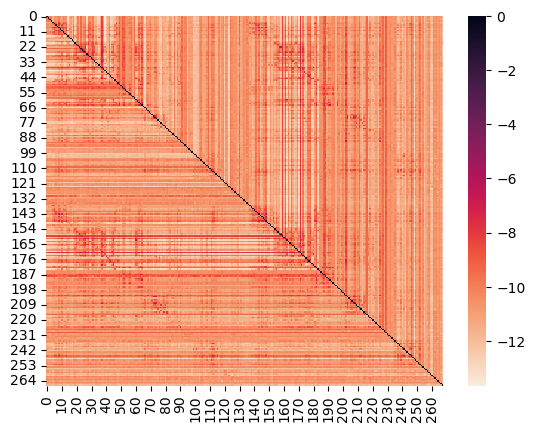

In [53]:
sns.heatmap(fc, cmap="rocket_r")

<Axes: >

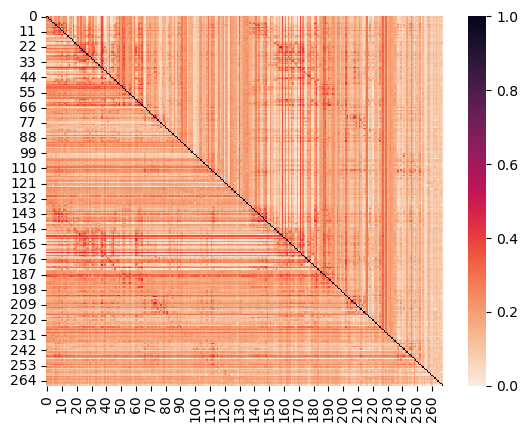

In [54]:
sns.heatmap(MinMaxScaler().fit_transform(fc), cmap='rocket_r')

<Axes: >

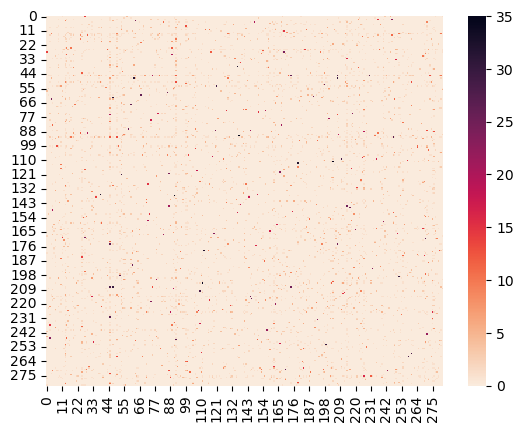

In [31]:
sns.heatmap(latt, cmap="rocket_r")

<Axes: >

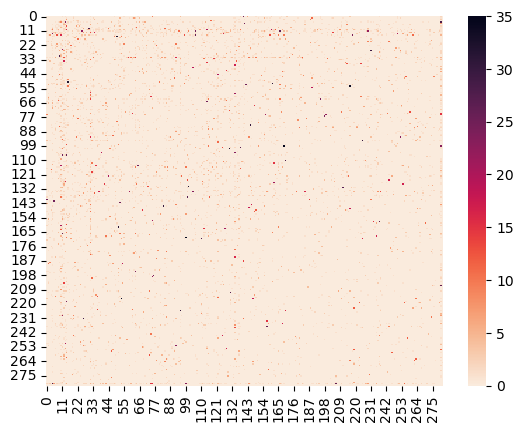

In [30]:
sns.heatmap(rand, cmap="rocket_r")

In [2]:
elegans = pd.read_excel('NeuronConnect_C_elegans.xls')
elegans['weight'] = elegans['Nbr']

In [24]:
elegans

,Neuron 1,Neuron 2,Type,Nbr,weight
0,ADAR,ADAL,EJ,1,1
1,ADFL,ADAL,EJ,1,1
2,ASHL,ADAL,EJ,1,1
3,AVDR,ADAL,EJ,2,2
4,PVQL,ADAL,EJ,1,1
...,...,...,...,...,...
6412,VD09,NMJ,NMJ,28,28
6413,VD10,NMJ,NMJ,22,22
6414,VD11,NMJ,NMJ,11,11
6415,VD12,NMJ,NMJ,13,13


In [3]:
G = nx.from_pandas_edgelist(df=elegans, source='Neuron 1', target='Neuron 2', edge_attr='weight')
elegans_adj = nx.adjacency_matrix(G).toarray()

In [10]:
G = nx.Graph(sc)
nx.is_connected(G)

True

<Axes: >

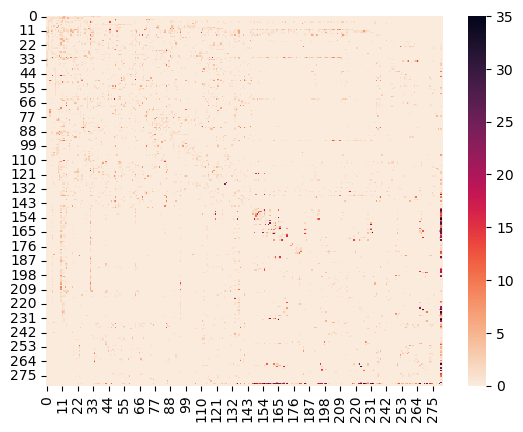

In [6]:
sns.heatmap(elegans_adj, cmap='rocket_r')

In [29]:
latt, _, _, _ = latmio_und(R=elegans_adj, itr=2)
rand, _ = randmio_und(R=elegans_adj, itr=2)

<Axes: >

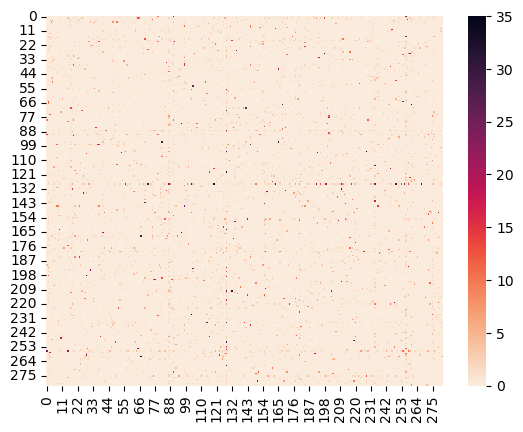

In [28]:
sns.heatmap(latt, cmap='rocket_r')

<Axes: >

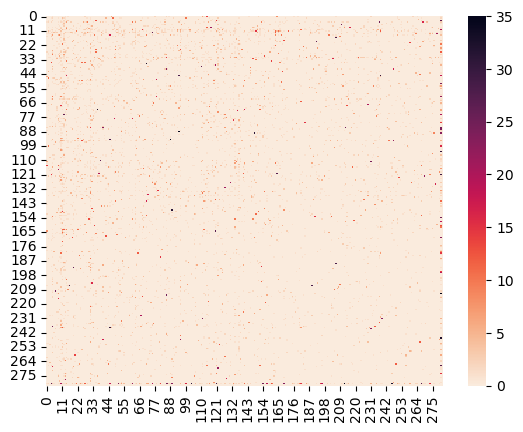

In [30]:
sns.heatmap(rand, cmap='rocket_r')

In [5]:
sc = np.load('/home/gbz6qn/Documents/research/data/hcp_shen_sc/sub-100206_parc-shen268_tract-prob_sc.npy')

<Axes: >

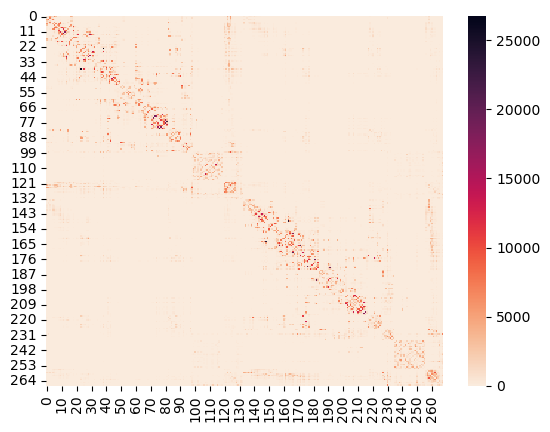

In [19]:
sns.heatmap(sc, cmap='rocket_r')

In [27]:
alpha = 0.05
G = nx.Graph(fc)
G = disparity_filter(G)
G2 = nx.Graph([(u, v, d) for u, v, d in G.edges(data=True) if d['alpha'] < alpha])
g2_adj = nx.adjacency_matrix(G2).toarray()
print('original: nodes = %s, edges = %s' % (G.number_of_nodes(), G.number_of_edges()))
print('backbone: nodes = %s, edges = %s' % (G2.number_of_nodes(), G2.number_of_edges()))

original: nodes = 268, edges = 35778
backbone: nodes = 85, edges = 99


<Axes: >

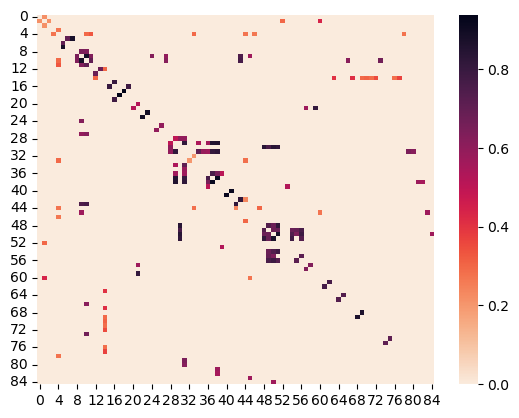

In [28]:
sns.heatmap(g2_adj, cmap='rocket_r')

In [29]:
np.min(g2_adj)

np.float64(0.0)

In [5]:
s = fc * (sc > 0)

<Axes: >

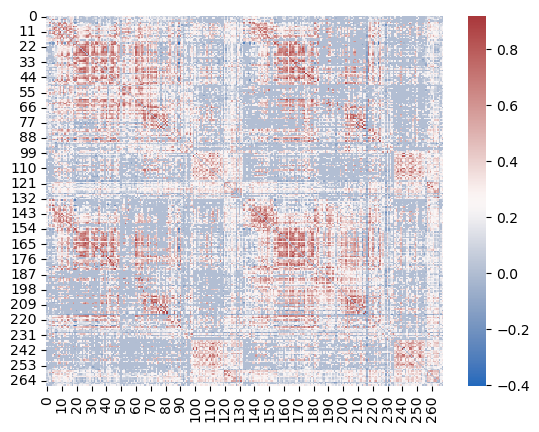

In [6]:
sns.heatmap(s, cmap='vlag')

In [12]:
g_efa = pd.read_csv('/home/gbz6qn/Documents/research/data/coupling/hcp/g_efa.csv')
subs = g_efa['id'].tolist()

In [13]:
# See if all SC graphs are fully connected
connected = []
disconnected = []
for sub in subs:
    sc = np.load(f'/home/gbz6qn/Documents/research/data/hcp_shen_sc/sub-{sub}_parc-shen268_tract-prob_sc.npy')
    G = nx.Graph(sc)
    if nx.is_connected(G):
        connected.append(sub)
    else:
        disconnected.append(sub)

In [14]:
len(subs)

329

In [15]:
len(connected)

329

### all HCP SC matrices are fully connected